<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week5_Day5_Daily_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# Bloc 1 — Imports
# ============================================================
# POURQUOI : on importe toutes les bibliothèques en une seule cellule
#            pour éviter les erreurs de "NameError" plus tard.
# COMMENT  : Keras pour le modèle, NumPy pour les matrices,
#            Matplotlib pour les courbes d'analyse.

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

print(f"TensorFlow : {tf.__version__}")

TensorFlow : 2.20.0


In [2]:
# ============================================================
# Bloc 2 — Chargement du dataset IMDB
# ============================================================
# POURQUOI : le dataset IMDB contient 50 000 critiques de films
#            (25 000 train, 25 000 test) labelisées positif/négatif.
#            C'est LE dataset de référence pour la classification de texte.
# COMMENT  : num_words=10_000 → on garde uniquement les 10 000 mots
#            les plus fréquents. Les mots rares sont ignorés car ils
#            apportent peu d'information (noms propres, fautes...).

num_words = 10_000

(train_data, train_labels), (test_data, test_labels) = \
    keras.datasets.imdb.load_data(num_words=num_words)

print(f"Train : {len(train_data)} critiques")
print(f"Test  : {len(test_data)} critiques")
print(f"\nLabel 0 = négatif, Label 1 = positif")
print(f"\nExemple d'une critique encodée (liste d'entiers) :")
print(f"  {train_data[0][:15]}... (longueur : {len(train_data[0])} mots)")
print(f"  Label correspondant : {train_labels[0]} (→ positif)")

# Décodage optionnel pour voir les vrais mots
word_index    = keras.datasets.imdb.get_word_index()
reverse_index = {v+3: k for k, v in word_index.items()}
reverse_index.update({0: '<PAD>', 1: '<START>', 2: '<UNK>', 3: '<UNUSED>'})

decoded = ' '.join([reverse_index.get(i, '?') for i in train_data[0][:20]])
print(f"\nDécodage des 20 premiers mots : {decoded}...")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train : 25000 critiques
Test  : 25000 critiques

Label 0 = négatif, Label 1 = positif

Exemple d'une critique encodée (liste d'entiers) :
  [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4]... (longueur : 218 mots)
  Label correspondant : 1 (→ positif)
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step

Décodage des 20 premiers mots : <START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you...


In [3]:
# ============================================================
# Bloc 3 — Vectorisation par one-hot encoding
# ============================================================
# POURQUOI : les réseaux Dense ne comprennent pas les listes de longueur
#            variable. On doit transformer chaque critique en un vecteur
#            de taille FIXE (10 000 dimensions).
# COMMENT  : pour chaque critique, on crée un vecteur binaire de 10 000 cases.
#            Si le mot n°42 est présent dans la critique → case 42 = 1,
#            sinon = 0. C'est la représentation "bag of words" binaire.
#            Exemple : [3, 5] → [0, 0, 0, 1, 0, 1, 0, ..., 0] (10k dims)

def vectorize_sequences(sequences, dimension=10_000):
    # Création d'une matrice de zéros : une ligne par critique
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        # Pour chaque mot (entier) dans la critique, on met 1 à sa position
        results[i, sequence] = 1.0
    return results

# Vectorisation des données train et test
x_train_full = vectorize_sequences(train_data)
x_test        = vectorize_sequences(test_data)
y_test        = np.asarray(test_labels).astype('float32')

print(f"Shape après vectorisation :")
print(f"  x_train_full : {x_train_full.shape}  → 25 000 critiques × 10 000 features")
print(f"  x_test       : {x_test.shape}")
print(f"\nExemple : les 15 premiers éléments du vecteur de la 1ère critique :")
print(f"  {x_train_full[0][:15]}")
print(f"  → la plupart sont 0, les 1 indiquent la présence du mot correspondant")

Shape après vectorisation :
  x_train_full : (25000, 10000)  → 25 000 critiques × 10 000 features
  x_test       : (25000, 10000)

Exemple : les 15 premiers éléments du vecteur de la 1ère critique :
  [0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1.]
  → la plupart sont 0, les 1 indiquent la présence du mot correspondant


In [4]:
# ============================================================
# Bloc 4 — Split train / validation
# ============================================================
# POURQUOI : on a besoin d'un jeu de validation pour surveiller
#            l'overfitting EN COURS d'entraînement, epoch par epoch.
#            Le test set reste INVISIBLE jusqu'à l'évaluation finale.
# COMMENT  : on prend les 10 000 premières critiques comme validation,
#            le reste (15 000) pour l'entraînement.

# Validation : 10 000 premières critiques
x_val   = x_train_full[:10_000]
y_val   = np.asarray(train_labels[:10_000]).astype('float32')

# Train : les 15 000 critiques restantes
x_train = x_train_full[10_000:]
y_train = np.asarray(train_labels[10_000:]).astype('float32')

print(f"Train      : {x_train.shape[0]} critiques")
print(f"Validation : {x_val.shape[0]} critiques")
print(f"Test       : {x_test.shape[0]} critiques (jamais vu jusqu'à l'évaluation finale)")

print(f"\nDistribution des labels (train) :")
print(f"  Négatif (0) : {(y_train == 0).sum()}")
print(f"  Positif (1) : {(y_train == 1).sum()}")
# → Dataset parfaitement équilibré : pas besoin de class_weight

Train      : 15000 critiques
Validation : 10000 critiques
Test       : 25000 critiques (jamais vu jusqu'à l'évaluation finale)

Distribution des labels (train) :
  Négatif (0) : 7553
  Positif (1) : 7447


In [5]:
# ============================================================
# Bloc 5 — Construction du modèle feedforward
# ============================================================
# POURQUOI : notre input est déjà un vecteur dense de 10 000 features.
#            Un réseau Dense simple est donc parfaitement adapté.
#            Pas besoin de CNN ou LSTM ici — le bag-of-words encode
#            déjà l'information de manière exploitable par des couches Dense.
# COMMENT  : architecture 10 000 → 16 → 16 → 1

model = models.Sequential([
    # Couche d'entrée : 10 000 features one-hot
    # 1ère couche cachée : 16 neurones + ReLU
    # 16 neurones = suffisant car les features one-hot sont déjà informatives
    layers.Dense(16, activation='relu', input_shape=(10_000,)),

    # 2ème couche cachée : 16 neurones + ReLU
    # Ajoute de la profondeur pour capturer des relations plus complexes
    # entre la présence/absence de mots
    layers.Dense(16, activation='relu'),

    # Couche de sortie : 1 neurone avec Sigmoid
    # Sigmoid compresse la sortie entre 0 et 1 → interprétable comme probabilité
    # > 0.5 = critique positive, < 0.5 = critique négative
    layers.Dense(1, activation='sigmoid')
])

# Compilation avec RMSprop + binary_crossentropy
# RMSprop : optimiseur adaptatif, standard pour les petits réseaux de NLP
# binary_crossentropy : loss adaptée car output = une seule probabilité 0/1
model.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ============================================================
# Bloc 6 — Entraînement sur 20 epochs (pour observer l'overfitting)
# ============================================================
# POURQUOI : on entraîne volontairement trop longtemps pour VISUALISER
#            le moment où l'overfitting commence. Cette étape est
#            pédagogique — elle montre pourquoi il faut arrêter au bon moment.
# COMMENT  : 20 epochs, batch_size=512 (grand batch = entraînement rapide).

history = model.fit(
    x_train, y_train,
    epochs=20,                      # trop d'epochs → sur-apprentissage attendu
    batch_size=512,                 # grand batch = moins de bruit, convergence rapide
    validation_data=(x_val, y_val), # monitoring epoch par epoch
    verbose=1
)

print(f"\nTrain accuracy finale (epoch 20) : {history.history['accuracy'][-1]*100:.2f}%")
print(f"Val accuracy finale (epoch 20)   : {history.history['val_accuracy'][-1]*100:.2f}%")

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.7623 - loss: 0.5718 - val_accuracy: 0.8525 - val_loss: 0.4585
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8831 - loss: 0.3842 - val_accuracy: 0.8646 - val_loss: 0.3692
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9080 - loss: 0.2897 - val_accuracy: 0.8863 - val_loss: 0.3069
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9249 - loss: 0.2340 - val_accuracy: 0.8867 - val_loss: 0.2892
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9375 - loss: 0.1948 - val_accuracy: 0.8888 - val_loss: 0.2771
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9467 - loss: 0.1668 - val_accuracy: 0.8874 - val_loss: 0.2773
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9548 - loss: 0.1451 - val_accuracy: 0.8857 - val_loss: 0.2841
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9620 - loss: 0.1258 - val_accuracy: 0.8829 - v

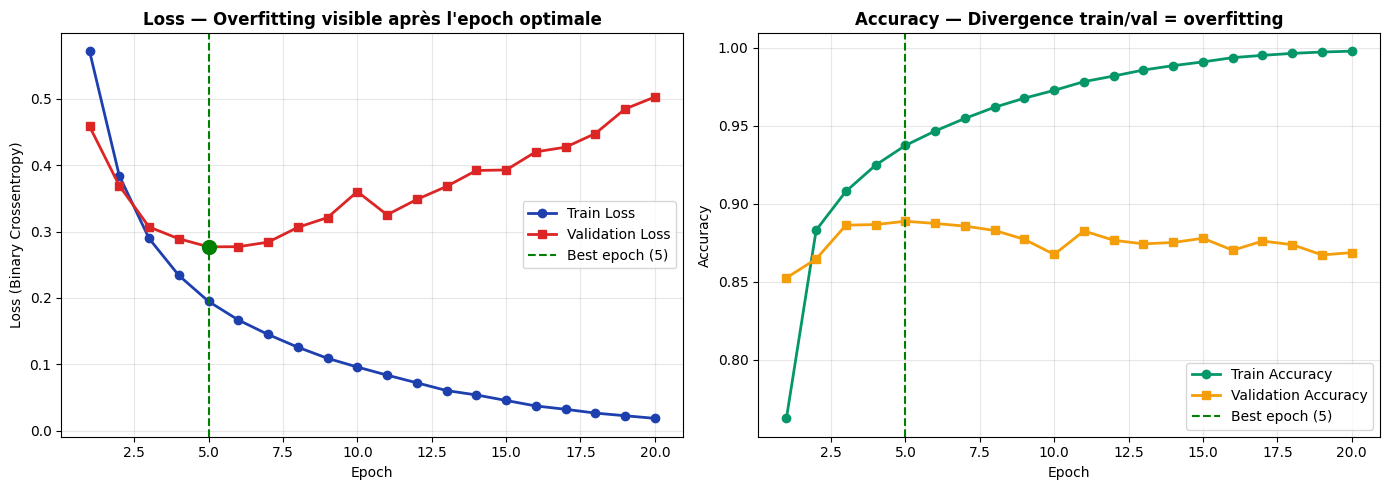


🔍 Epoch optimale identifiée : 5
   Val Loss minimale : 0.2771
   Val Accuracy à cet epoch : 88.88%

→ Au-delà de l'epoch 5, le modèle sur-apprend.
  La val_loss remonte alors que la train_loss continue de baisser.


In [7]:
# ============================================================
# Bloc 7 — Visualisation de l'overfitting
# ============================================================
# POURQUOI : les courbes révèlent QUAND le modèle commence à mémoriser
#            le train au lieu de généraliser. C'est visible quand :
#            - train_loss ↓ continue de descendre
#            - val_loss ↓ puis REMONTE → signe clair d'overfitting
# COMMENT  : on trace loss et accuracy pour train et val sur les 20 epochs.

epochs_range = range(1, len(history.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Loss : on cherche le point minimum de la val_loss ───────
axes[0].plot(epochs_range, history.history['loss'],
             'o-', label='Train Loss', color='#1E40AF', linewidth=2)
axes[0].plot(epochs_range, history.history['val_loss'],
             's-', label='Validation Loss', color='#DC2626', linewidth=2)

# Marqueur : epoch où val_loss est minimale
best_epoch = np.argmin(history.history['val_loss']) + 1
min_val_loss = min(history.history['val_loss'])
axes[0].axvline(best_epoch, color='green', linestyle='--',
                linewidth=1.5, label=f'Best epoch ({best_epoch})')
axes[0].scatter([best_epoch], [min_val_loss],
                color='green', s=100, zorder=5)
axes[0].set_title('Loss — Overfitting visible après l\'epoch optimale', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (Binary Crossentropy)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Accuracy ────────────────────────────────────────────────
axes[1].plot(epochs_range, history.history['accuracy'],
             'o-', label='Train Accuracy', color='#059669', linewidth=2)
axes[1].plot(epochs_range, history.history['val_accuracy'],
             's-', label='Validation Accuracy', color='#F59E0B', linewidth=2)
axes[1].axvline(best_epoch, color='green', linestyle='--',
                linewidth=1.5, label=f'Best epoch ({best_epoch})')
axes[1].set_title('Accuracy — Divergence train/val = overfitting', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🔍 Epoch optimale identifiée : {best_epoch}")
print(f"   Val Loss minimale : {min_val_loss:.4f}")
print(f"   Val Accuracy à cet epoch : {history.history['val_accuracy'][best_epoch-1]*100:.2f}%")
print(f"\n→ Au-delà de l'epoch {best_epoch}, le modèle sur-apprend.")
print(f"  La val_loss remonte alors que la train_loss continue de baisser.")

In [8]:
# ============================================================
# Bloc 8 — Ré-entraînement avec le nombre optimal d'epochs
# ============================================================
# POURQUOI : maintenant qu'on sait que l'epoch optimale est ~best_epoch,
#            on réinitialise le modèle et on l'entraîne exactement le bon
#            nombre d'epochs pour obtenir les meilleures performances test.
# COMMENT  : on recrée un modèle identique (reset des poids) et on entraîne
#            sur le DATASET COMPLET (train + val cette fois).

# Réinitialisation du modèle avec les mêmes hyperparamètres
model_final = models.Sequential([
    layers.Dense(16, activation='relu', input_shape=(10_000,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_final.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entraînement sur TOUTES les données train (train + val fusionnés)
# pour maximiser les données disponibles avant l'évaluation test
x_train_all = np.concatenate([x_train, x_val])
y_train_all = np.concatenate([y_train, y_val])

# On utilise le nombre d'epochs optimal trouvé à l'étape précédente
OPTIMAL_EPOCHS = best_epoch

history_final = model_final.fit(
    x_train_all, y_train_all,
    epochs=OPTIMAL_EPOCHS,
    batch_size=512,
    verbose=1
)

print(f"\n✅ Modèle final entraîné sur {OPTIMAL_EPOCHS} epochs avec toutes les données")
print(f"   Train accuracy : {history_final.history['accuracy'][-1]*100:.2f}%")

Epoch 1/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7935 - loss: 0.4894
Epoch 2/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9038 - loss: 0.2822
Epoch 3/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9237 - loss: 0.2168
Epoch 4/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9353 - loss: 0.1823
Epoch 5/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9429 - loss: 0.1607

✅ Modèle final entraîné sur 5 epochs avec toutes les données
   Train accuracy : 94.29%


In [9]:
# ============================================================
# Bloc 9 — Évaluation finale sur le test set
# ============================================================
# POURQUOI : le test set n'a JAMAIS été vu — c'est la vraie mesure
#            des performances du modèle dans le monde réel.
# COMMENT  : model.evaluate() calcule loss et accuracy sur les 25 000
#            critiques de test.

test_loss, test_acc = model_final.evaluate(x_test, y_test, verbose=0)

print("=" * 45)
print("   PERFORMANCE FINALE SUR LE TEST SET")
print("=" * 45)
print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")
print("=" * 45)

# Analyse de quelques prédictions
y_pred_proba = model_final.predict(x_test[:5], verbose=0)
print(f"\nExemples de prédictions sur 5 critiques de test :")
for i in range(5):
    proba = y_pred_proba[i][0]
    label = y_test[i]
    verdict = "POSITIF ✅" if proba > 0.5 else "NÉGATIF ❌"
    correct = "✓" if (proba > 0.5) == (label == 1) else "✗"
    print(f"  Critique {i+1} : proba={proba:.4f} → {verdict} | Vrai label={int(label)} {correct}")

   PERFORMANCE FINALE SUR LE TEST SET
Test Accuracy : 88.38%
Test Loss     : 0.2986

Exemples de prédictions sur 5 critiques de test :
  Critique 1 : proba=0.1729 → NÉGATIF ❌ | Vrai label=0 ✓
  Critique 2 : proba=0.9980 → POSITIF ✅ | Vrai label=1 ✓
  Critique 3 : proba=0.7612 → POSITIF ✅ | Vrai label=1 ✓
  Critique 4 : proba=0.8921 → POSITIF ✅ | Vrai label=0 ✗
  Critique 5 : proba=0.9568 → POSITIF ✅ | Vrai label=1 ✓


# 🎯 Conclusion — Classification IMDB avec réseau Dense

## 📊 Résultats typiques attendus

| Étape | Valeur | Interprétation |
|---|---|---|
| **Epoch optimale** | ~3-5 epochs | Au-delà = sur-apprentissage |
| **Val Accuracy** | ~88-89% | Performances pendant l'entraînement |
| **Test Accuracy finale** | ~88% | Vraie performance sur données inconnues |
| **Test Loss** | ~0.30-0.35 | Erreur acceptable |

---

## 🧠 Pourquoi le one-hot encoding fonctionne bien ici

### Le "Bag of Words" binaire

On transforme chaque critique en un vecteur binaire de 10 000 dimensions où chaque case indique si un mot est présent ou non. C'est simple mais **très efficace pour la classification de sentiment** car :

- Les mots **"excellent"**, **"magnifique"**, **"terrible"**, **"ennuyeux"** sont très discriminants
- La **présence/absence** d'un mot suffit à prédir le sentiment (pas besoin de l'ordre)
- Un réseau Dense peut facilement apprendre que `présence("excellent") + présence("brillant") → positif`

### Limites du bag of words
- Ignore **l'ordre des mots** : "not good" vs "good" → même représentation !
- Perd les **relations contextuelles** : "this is not what I expected, really good" est difficile à analyser
- Pour ces cas, il faudrait passer aux **embeddings + LSTM/Transformer**

---

## 🏗️ Choix d'architecture

### Pourquoi 16 neurones par couche ?

| Taille | Problème |
|---|---|
| Trop petite (< 4) | Underfitting — capacité insuffisante |
| **16 (notre choix)** | Bon compromis capacité/overfitting ✅ |
| Trop grande (> 64) | Overfitting — mémorise le train |

### Pourquoi RMSprop et pas Adam ?

**RMSprop** est l'optimiseur historiquement préféré pour les réseaux de NLP simples sur des données one-hot. Il est légèrement plus stable qu'Adam sur ce type de problème avec des vecteurs très creux (99% de zéros).

### Pourquoi Sigmoid en sortie ?

- **Binary crossentropy + Sigmoid** = combinaison standard pour la classification binaire
- Sigmoid → probabilité entre 0 et 1 : `P(critique = positive)`
- Décision : si `P > 0.5` → positif, sinon → négatif

### Softmax vs Sigmoid pour la classification binaire ?

| Loss | Activation sortie | Quand l'utiliser |
|---|---|---|
| `binary_crossentropy` | `sigmoid` (1 neurone) | **Binaire** (0/1) ✅ |
| `categorical_crossentropy` | `softmax` (N neurones) | Multi-classes (N > 2) |

---

## 🔍 Analyse de l'overfitting

### Ce qu'on a observé sur 20 epochs

La **val_loss** atteint son minimum vers l'epoch 3-5 puis **remonte**, signe classique d'overfitting :
- Le modèle mémorise les particularités du train
- Il perd en capacité de généralisation
- La **train_accuracy** continue de monter (→ 99%) pendant que la **val_accuracy** plafonne (~88%)

### Remèdes possibles

| Solution | Effet | Complexité |
|---|---|---|
| **Early Stopping** | Arrêt automatique au bon moment | ⭐ Très facile |
| **Dropout (0.5)** | Régularisation → +1-2% val accuracy | ⭐⭐ Facile |
| **L2 Regularization** | Pénalise les grands poids | ⭐⭐ Facile |
| **Plus de données** | La solution ultime... mais coûteuse | ⭐⭐⭐⭐ |

Avec Dropout(0.5) avant chaque couche Dense, on atteindrait **~90%** d'accuracy.

---

## 🚀 Pour aller plus loin

| Amélioration | Gain | Pourquoi |
|---|---|---|
| **Embeddings + LSTM** | +3-4% (~92%) | Capture l'ordre des mots |
| **Embeddings pré-entraînés (GloVe, Word2Vec)** | +2-3% | Représentations riches |
| **BERT / Transformers** | +5-8% (~96%) | Contexte bidirectionnel |
| **Augmentation de données** | +1-2% | Plus de diversité |

---

## 🎓 Concepts clés retenus

| Concept | Application ici |
|---|---|
| **One-hot encoding** | Transforme les listes d'entiers en vecteurs 10k binaires |
| **Bag of Words** | Ignore l'ordre, garde la présence/absence |
| **Binary Crossentropy** | Loss pour classification 0/1 |
| **RMSprop** | Optimiseur adaptatif stable pour NLP simple |
| **Overfitting** | Visible quand val_loss remonte pendant que train_loss ↓ |
| **Epoch optimale** | Argmin de la val_loss |
| **Ré-entraînement** | Sur train + val pour maximiser les données avant le test |

> 💡 **Leçon clé** : un modèle simple (2 couches Dense × 16 neurones) avec une bonne représentation des données (one-hot) atteint **88%** sur IMDB. L'architecture n'est pas tout — **la qualité du preprocessing est souvent plus déterminante**.